# Part 13: Localizing an ensemble Kalman filter

The ensemble Kalman filter (EnKF) learns how an observation should update the state from the empirical covariance of its ensemble. That is attractive because it avoids derivatives, but a small ensemble can invent strong relationships between state variables that are actually far apart. **Localization** damps those spurious long-range relationships.

In this tutorial we will:

- simulate a 40-dimensional Lorenz–96 system,
- run the same 10-member EnKF with and without localization, and
- compare the recovered trajectories and root mean squared error (RMSE).

Localization adds one configuration object: `EnKFLocalizationConfig`.

## Why localization helps

Let $C_{xy}$ be the empirical covariance between the state $x$ and predicted observation $y$. The EnKF uses this matrix to decide how each observation changes every state coordinate. With $N=10$ ensemble members, however, the covariance has rank at most $N-1=9$ even though the state has 40 coordinates. Sampling noise can therefore create implausible corrections at distant locations.

A distance-based localization replaces the empirical cross-covariance by

$$
\widetilde C_{xy} = L_{xy} \odot C_{xy},
$$

where $L_{xy}$ is a matrix of taper weights and $\odot$ denotes elementwise multiplication. Nearby state–observation pairs receive weights near one; sufficiently distant pairs receive weights near zero. We similarly taper the matrix $C_{yy}$.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from cuthbertlib.ensemble_kalman.localization import gaspari_cohn

import dynestyx as dsx
from dynestyx import DynamicalModel, Filter, LinearGaussianObservation
from dynestyx.inference.configs.discretizer import ODEFlowConfig
from dynestyx.inference.filters import EnKFConfig, EnKFLocalizationConfig

jax.config.update("jax_enable_x64", True)

WARM_RED = "#E64B35"
TEAL = "#009E73"
TRUTH_COLOR = "#222222"
OBSERVATION_COLOR = "#6F6F6F"

mpl.rcParams.update(
    {
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "DejaVu Sans",
        "mathtext.fontset": "dejavusans",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.9,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": False,
    }
)

default_figure_dir = (
    Path("docs/tutorials/gentle_intro/figures")
    if Path("docs").exists()
    else Path("figures")
)
FIGURE_DIR = default_figure_dir
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.pdf")
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300)


def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

## The Lorenz–96 experiment

Lorenz–96 is a standard chaotic test system with variables arranged on a periodic ring. For coordinate $i$,

$$
\frac{d x_i}{dt} = (x_{i+1} - x_{i-2})x_{i-1} - x_i + F,
$$

with indices interpreted cyclically. We set $F=8$ and use `dsx.simulate` to integrate the continuous-time model with the default Tsit5 solver and a fixed step of $0.01$. Every $0.05$ time units, we observe the even-numbered coordinates with independent Gaussian noise. The filter uses `Discretizer` with `ODEFlowConfig` and the same solver settings. Its transition is deterministic; uncertainty comes from the initial ensemble and observation noise.

In [2]:
STATE_DIM = 40
FORCING = 8.0
MODEL_DT = 0.01
OBSERVATION_INTERVAL = 0.05
SPINUP_TIME = 20.0
N_CYCLES = 250
OBSERVED_INDICES = jnp.arange(0, STATE_DIM, 2)
OBSERVATION_SD = 1.0
N_ENSEMBLE = 10
INFLATION_DELTA = 0.05
LOCALIZATION_RADIUS = 8.0


def lorenz96_tendency(x, u, t):
    return (jnp.roll(x, -1) - jnp.roll(x, 2)) * jnp.roll(x, 1) - x + FORCING


observation_matrix = jnp.eye(STATE_DIM)[OBSERVED_INDICES]
ode_config = dsx.ODESimulatorConfig(dt0=MODEL_DT)


def lorenz96_dynamics(initial_condition):
    return DynamicalModel(
        initial_condition=initial_condition,
        state_evolution=dsx.ContinuousTimeStateEvolution(drift=lorenz96_tendency),
        observation_model=LinearGaussianObservation(
            H=observation_matrix,
            R=OBSERVATION_SD**2 * jnp.eye(len(OBSERVED_INDICES)),
        ),
    )

We first use `dsx.simulate` to spin up the dynamics for 20 time units so that the retained trajectory lies on the chaotic attractor. Fixed random seeds generate the observation errors and the imperfect initial estimate, making every comparison reproducible.

In [3]:
near_equilibrium = FORCING * jnp.ones(STATE_DIM)
near_equilibrium = near_equilibrium.at[0].add(0.01)
spinup = dsx.simulate(
    lorenz96_dynamics(dist.Delta(near_equilibrium, event_dim=1)),
    rng_key=jr.PRNGKey(0),
    predict_times=jnp.array([0.0, SPINUP_TIME]),
    simulator_config=ode_config,
)
spinup_state = spinup.states[0, -1]

times = OBSERVATION_INTERVAL * jnp.arange(N_CYCLES)
simulation = dsx.simulate(
    lorenz96_dynamics(dist.Delta(spinup_state, event_dim=1)),
    rng_key=jr.PRNGKey(2026),
    predict_times=times,
    simulator_config=ode_config,
)
# dsx.simulate retains a simulation axis even for a single trajectory.
truth = simulation.states[0]
observations = simulation.observations[0]
initial_mean = truth[0] + 0.5 * jr.normal(jr.PRNGKey(2027), (STATE_DIM,))

dynamics = lorenz96_dynamics(
    dist.MultivariateNormal(
        loc=initial_mean,
        covariance_matrix=jnp.eye(STATE_DIM),
    )
)
discretizer_config = ODEFlowConfig(simulator_config=ode_config)

print(f"truth shape: {truth.shape}")
print(f"observation shape: {observations.shape}")
print(f"observed coordinates: {np.asarray(OBSERVED_INDICES)}")

truth shape: (250, 40)
observation shape: (250, 20)
observed coordinates: [ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38]


## Build a periodic distance matrix

The state coordinates live on a ring, so coordinates 0 and 39 are neighbors rather than opposite ends. The distance between coordinates $i$ and $j$ is therefore

$$
d(i,j) = \min\bigl(|i-j|, 40-|i-j|\bigr).
$$

`state_observation_distances` must have shape `(state_dim, observation_dim)`. Here its rows correspond to all 40 state coordinates and its columns correspond to the 20 observed coordinates. We choose the compactly supported Gaspari–Cohn taper with a full support radius of 8 lattice sites.

In [4]:
state_locations = jnp.arange(STATE_DIM)[:, None]
observation_locations = OBSERVED_INDICES[None, :]
direct_distances = jnp.abs(state_locations - observation_locations)
state_observation_distances = jnp.minimum(
    direct_distances, STATE_DIM - direct_distances
)

localization = EnKFLocalizationConfig(
    state_observation_distances=state_observation_distances,
    taper="gaspari_cohn",
    taper_scale=LOCALIZATION_RADIUS,
)

localization

EnKFLocalizationConfig(state_observation_distances=Array([[ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 18, 16, 14, 12, 10,
         8,  6,  4,  2],
       [ 1,  1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 19, 17, 15, 13, 11,
         9,  7,  5,  3],
       [ 2,  0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 18, 16, 14, 12,
        10,  8,  6,  4],
       [ 3,  1,  1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 19, 17, 15, 13,
        11,  9,  7,  5],
       [ 4,  2,  0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 18, 16, 14,
        12, 10,  8,  6],
       [ 5,  3,  1,  1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 19, 17, 15,
        13, 11,  9,  7],
       [ 6,  4,  2,  0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 18, 16,
        14, 12, 10,  8],
       [ 7,  5,  3,  1,  1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 19, 17,
        15, 13, 11,  9],
       [ 8,  6,  4,  2,  0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 18,
        16, 14, 12, 10],
       [ 9,  7,  5,  3,  1,  1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 19,
    

The left panel below shows the one-dimensional taper. The right panel shows the complete state–observation taper matrix. Its wrap-around bands are a direct consequence of periodic distance.

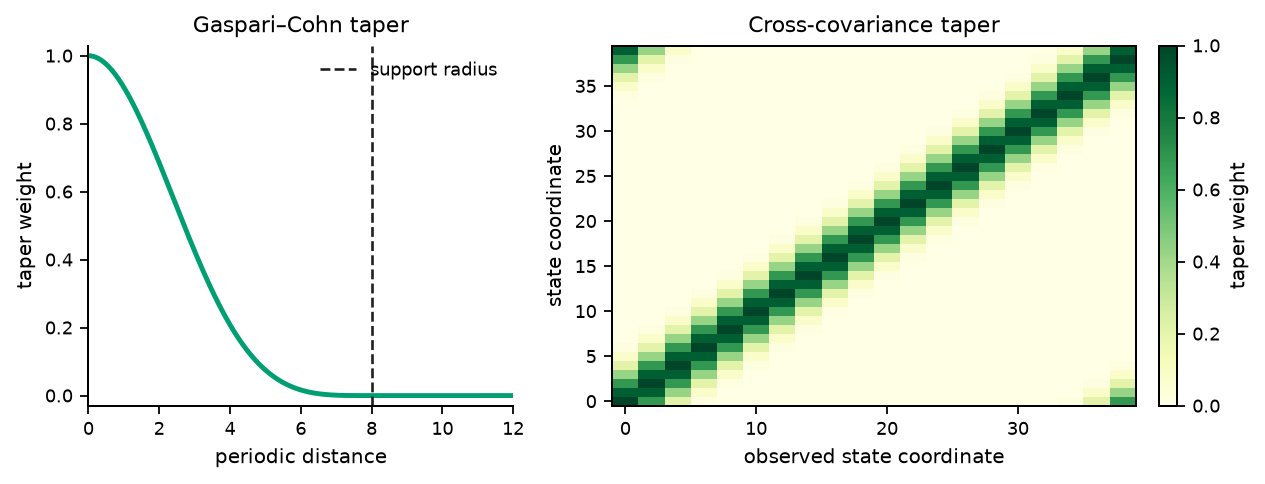

In [5]:
distance_grid = jnp.linspace(0.0, 12.0, 241)
taper_matrix = gaspari_cohn(
    state_observation_distances, LOCALIZATION_RADIUS
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.0, 3.1),
    gridspec_kw={"width_ratios": [1.0, 1.35]},
)

axes[0].plot(
    distance_grid,
    gaspari_cohn(distance_grid, LOCALIZATION_RADIUS),
    color=TEAL,
    linewidth=2.2,
)
axes[0].axvline(
    LOCALIZATION_RADIUS,
    color=TRUTH_COLOR,
    linestyle="--",
    linewidth=1.2,
    label="support radius",
)
axes[0].set(
    xlabel="periodic distance",
    ylabel="taper weight",
    title="Gaspari–Cohn taper",
    xlim=(0.0, 12.0),
    ylim=(-0.03, 1.03),
)
axes[0].legend(loc="upper right")
despine(axes[0])

image = axes[1].imshow(
    np.asarray(taper_matrix),
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="YlGn",
    vmin=0.0,
    vmax=1.0,
)
axes[1].set(
    xlabel="observed state coordinate",
    ylabel="state coordinate",
    title="Cross-covariance taper",
)
column_ticks = np.arange(0, len(OBSERVED_INDICES), 5)
axes[1].set_xticks(column_ticks, np.asarray(OBSERVED_INDICES)[column_ticks])
for side in ("top", "right", "bottom", "left"):
    axes[1].spines[side].set_visible(True)
    axes[1].spines[side].set_linewidth(0.9)
colorbar = fig.colorbar(image, ax=axes[1], fraction=0.047, pad=0.04)
colorbar.set_label("taper weight")
fig.tight_layout()
save_figure(fig, "enkf_localization_taper")
plt.show()

## Attach localization to the EnKF

Localization is attached directly to `EnKFConfig`. All other settings are identical between the two filters, including the common-random-number seed. This makes the comparison reflect localization rather than a different random ensemble. We use the deterministic update (`perturb_measurements=False`) so fresh observation perturbations do not obscure the comparison; the fixed seed still controls the shared initial ensemble.

We leave `observation_distances=None`, its default. This requests **cross-only localization**: Dynestyx tapers $C_{xy}$ but leaves the empirical innovation covariance $C_{yy}+R$ unchanged. It is the smallest useful localization configuration.

In [6]:
common_enkf_options = dict(
    n_particles=N_ENSEMBLE,
    inflation_delta=INFLATION_DELTA,
    perturb_measurements=False,
    crn_seed=jr.PRNGKey(17),
    record_filtered_states_mean=True,
    include_predicted_observations=False,
    warn=False,
)

unlocalized_config = EnKFConfig(**common_enkf_options)
localized_config = EnKFConfig(
    **common_enkf_options,
    localization=localization,
)

The pure `dsx.condition` interface returns the complete filtering result without requiring a NumPyro model. For the Cuthbert EnKF backend, `result.states.mean` is the time-indexed filtered ensemble mean. The inner `Discretizer` converts our continuous-time model into deterministic transitions between observation times using the shared ODE solver settings.

In [7]:
def run_filter(filter_config):
    with Filter(filter_config=filter_config):
        with dsx.Discretizer(discretizer_config):
            result = dsx.condition(
                "f",
                dynamics,
                obs_times=times,
                obs_values=observations,
            )
    return result


unlocalized_result = run_filter(unlocalized_config)
localized_result = run_filter(localized_config)

unlocalized_mean = unlocalized_result.states.mean
localized_mean = localized_result.states.mean

print(f"filtered mean shape: {localized_mean.shape}")

filtered mean shape: (250, 40)


## Compare state recovery

We evaluate the full 40-dimensional state, including the 20 coordinates that were never observed directly. The first 50 cycles are excluded from the scalar summary so that it emphasizes tracking after the initial adjustment.

In [8]:
def state_rmse(estimate):
    return jnp.sqrt(jnp.mean(jnp.square(estimate - truth), axis=-1))


unlocalized_rmse = state_rmse(unlocalized_mean)
localized_rmse = state_rmse(localized_mean)
summary_slice = slice(50, None)
unlocalized_summary = float(jnp.mean(unlocalized_rmse[summary_slice]))
localized_summary = float(jnp.mean(localized_rmse[summary_slice]))
relative_reduction = 100.0 * (
    unlocalized_summary - localized_summary
) / unlocalized_summary

if not (np.isfinite(unlocalized_summary) and np.isfinite(localized_summary)):
    raise RuntimeError("The filtering comparison produced a non-finite RMSE.")

print(f"Mean RMSE after cycle 50, unlocalized: {unlocalized_summary:.3f}")
print(f"Mean RMSE after cycle 50, localized:   {localized_summary:.3f}")
print(f"Relative RMSE reduction:               {relative_reduction:.1f}%")

Mean RMSE after cycle 50, unlocalized: 4.564
Mean RMSE after cycle 50, localized:   1.409
Relative RMSE reduction:               69.1%


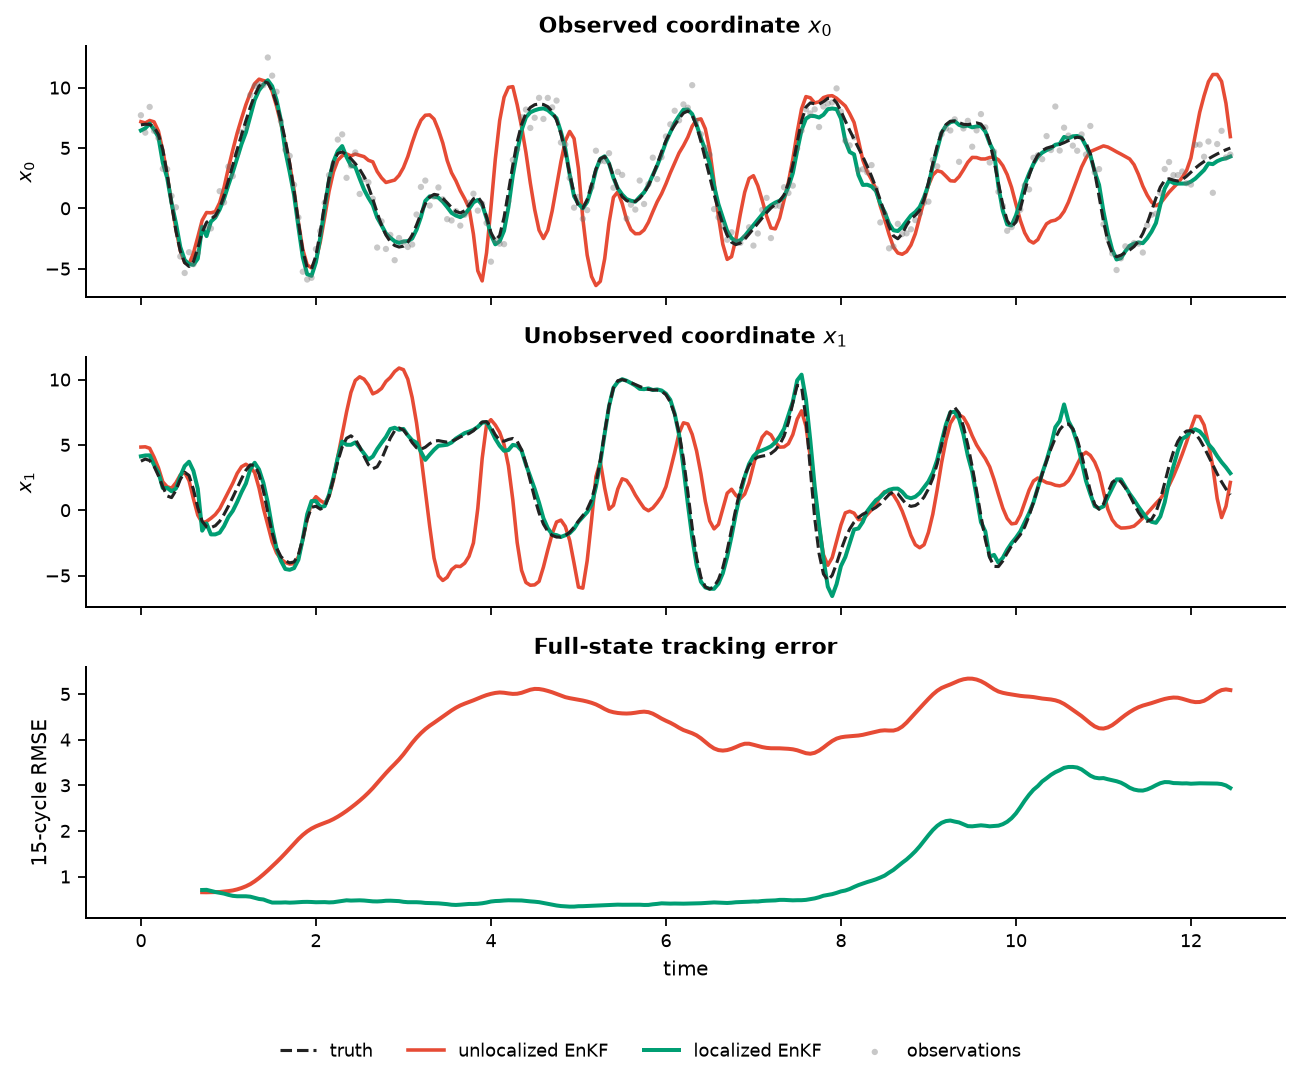

In [9]:
def moving_average(values, window=15):
    weights = np.ones(window) / window
    return np.convolve(np.asarray(values), weights, mode="valid")


fig, axes = plt.subplots(3, 1, figsize=(8.2, 6.7), sharex=True)

for ax, coordinate in zip(axes[:2], (0, 1), strict=True):
    ax.plot(
        times,
        truth[:, coordinate],
        color=TRUTH_COLOR,
        linestyle="--",
        linewidth=1.4,
        label="truth",
        zorder=4,
    )
    ax.plot(
        times,
        unlocalized_mean[:, coordinate],
        color=WARM_RED,
        linewidth=1.6,
        label="unlocalized EnKF",
    )
    ax.plot(
        times,
        localized_mean[:, coordinate],
        color=TEAL,
        linewidth=1.8,
        label="localized EnKF",
    )
    ax.set_ylabel(rf"$x_{{{coordinate}}}$")
    despine(ax)

axes[0].scatter(
    times,
    observations[:, 0],
    s=8,
    color=OBSERVATION_COLOR,
    alpha=0.38,
    edgecolors="none",
    label="observations",
    zorder=2,
)
axes[0].set_title(r"Observed coordinate $x_0$", fontweight="bold")
axes[1].set_title(r"Unobserved coordinate $x_1$", fontweight="bold")

rmse_window = 15
rmse_times = np.asarray(times)[rmse_window - 1 :]
axes[2].plot(
    rmse_times,
    moving_average(unlocalized_rmse, rmse_window),
    color=WARM_RED,
    linewidth=1.8,
    label="unlocalized EnKF",
)
axes[2].plot(
    rmse_times,
    moving_average(localized_rmse, rmse_window),
    color=TEAL,
    linewidth=1.8,
    label="localized EnKF",
)
axes[2].set(
    xlabel="time",
    ylabel="15-cycle RMSE",
    title="Full-state tracking error",
)
axes[2].title.set_fontweight("bold")
despine(axes[2])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
)
fig.tight_layout(rect=(0.0, 0.06, 1.0, 1.0))
save_figure(fig, "enkf_localization_state_recovery")
plt.show()

The localized EnKF uses the same observations, ensemble size, inflation, and random seed as the baseline. Its advantage comes only from suppressing implausible long-range entries in the estimated state–observation covariance. Notice that localization also helps the odd coordinate $x_1$, even though that coordinate is never observed directly: nearby even coordinates still carry useful information.

The radius is a modeling choice, not a universal constant. A very large radius approaches the unlocalized filter, while a very small radius can discard genuine relationships. Check out the [localization hyperparameter deep dive](../../deep_dives/l96_localization_hyperparameter_scoring.ipynb) to learn how to tune a Gaussian localization length scale with proper scoring rules and gradient-based optimization.

## Beyond the built-in taper

`EnKFLocalizationConfig` accepts either the built-in strings `"gaspari_cohn"` and `"gaussian"`, or a custom covariance function. A custom function receives the complete distance matrix and returns taper weights of the same shape. It can close over JAX parameters, which is useful when learning a taper:

```python
length_scale = jnp.array(3.0)

def my_gaussian_taper(distances):
    return jnp.exp(-0.5 * (distances / length_scale) ** 2)

custom_localization = EnKFLocalizationConfig(
    state_observation_distances=state_observation_distances,
    taper=my_gaussian_taper,
)
```

Leave `taper_scale=None` for a custom callable because its parameters belong to the callable itself. Advanced users who need to replace the covariance operations directly can instead attach an `EnKFLocalizationFunctions` callback bundle.

## Takeaways

- Small ensembles produce noisy long-range sample covariances, especially when the state dimension exceeds the ensemble size.
- Localization encodes a geometric belief about which observations should influence which state coordinates.
- For periodic systems, build distances with wrap-around.
- Attach `EnKFLocalizationConfig` through the `localization` field of `EnKFConfig`.
- Start with cross-only Gaspari–Cohn localization; add observation-space localization or learn a Gaussian scale when your application needs it.